# Orthogonalization Experiemnts
This colab shows the code setup we used for the orthogonalization experiments discussed in section 4.2 of our paper.

#Setup
Code for imports and model setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class XORMLP(nn.Module):
    """
    Simple MLP for XOR:
    2 inputs → hidden layer (tanh) → 1 output (sigmoid)
    """
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = torch.tanh(self.net[0](x))
        logits = self.net[2](h)
        out = torch.sigmoid(logits)
        return out, h

def generate_xor(n=200):
    """
    Generates XOR dataset:
    """
    X = torch.randint(0, 2, (n, 2)).float()
    y = (X[:, 0] != X[:, 1]).float().unsqueeze(1)
    return X.to(device), y.to(device)



Experiment setup

Code for computing effective rank, condition number, and multiplicity of circuit

In [ ]:
def compute_metrics(model, X):
    """
    Computes representation metrics from hidden activations:
    - condition number
    - effective rank

    """
    with torch.no_grad():
        _, H = model(X)
    H_np = (H - H.mean(0, keepdim=True)).detach().cpu().numpy()
    u, s, _ = np.linalg.svd(H_np, full_matrices=False)
    cond = (s[0] / s[-1]) if s[-1] > 1e-8 else np.inf
    p = s / s.sum()
    eff_rank = np.exp(-(p * np.log(p + 1e-10)).sum())
    return eff_rank, cond

def compute_multiplicity(model, X, y, tol=0.02):
    """
    Measures number of redundant neurons:
    - removes each neuron one at a time
    - checks if predictions stay the same
    """
    #Come back to this comment
    with torch.no_grad():
        y_full, _ = model(X)
    preds_full = (y_full > 0.5).float()
    n = model.net[0].out_features
    good = 0
    total = 0
    for i in range(n):
        mask = torch.ones(n, device=device)
        mask[i] = 0
        _, H = model(X)
        H_masked = H * mask
        logits_masked = model.net[2](H_masked)
        out = torch.sigmoid(logits_masked)
        preds = (out > 0.5).float()
        acc = (preds == preds_full).float().mean().item()
        if acc > 1 - tol:
            good += 1
        total += 1
    return good


# Running the Experiment

In [ ]:
"""
Runs experiment and gathers dataon different MLPs with varying widths, seeds, and orthogonalization regularization strengths

Data:
- Width
- Seed
- Lambda Orthogonalization
- Effective Rank
- Condition Number
- Multiplicity
"""
widths = [3, 4, 5, 6]
seeds = [0, 1, 2]
lambda_orths = [0.0, 1e-4, 1e-3, 1e-2]

for width in widths:
    for seed in seeds:
        torch.manual_seed(seed)
        X, y = generate_xor()
        for lam in lambda_orths:
            model = XORMLP(width).to(device)
            opt = optim.Adam(model.parameters(), lr=0.05)
            loss_fn = nn.BCELoss()

            """
            Trains model with with task loss and orthogonoalization regularization on hidden activations
            """
            for epoch in range(800):
                opt.zero_grad()
                y_pred, H = model(X)
                loss_task = loss_fn(y_pred, y)

                # Orthogonality regularization: (HᵀH - I)²
                HtH = H.T @ H / H.shape[0]
                ortho_loss = ((HtH - torch.eye(width, device=device)) ** 2).sum()

                loss = loss_task + lam * ortho_loss
                loss.backward()
                opt.step()

            eff_rank, cond = compute_metrics(model, X)
            mult = compute_multiplicity(model, X, y)

            records.append({
                "width": width,
                "seed": seed,
                "lambda_orth": lam,
                "eff_rank": eff_rank,
                "cond": cond,
                "multiplicity": mult
            })

df_orth = pd.DataFrame(records)
df_orth.head()

,width,seed,lambda_orth,eff_rank,cond,multiplicity
0,3,0,0.0000,2.890691,1.990044,1
1,3,0,0.0001,2.904536,1.892008,1
2,3,0,0.0010,2.899935,1.928606,1
3,3,0,0.0100,2.870580,2.040765,1
4,3,1,0.0000,2.887583,1.991494,1


# Displaying Data

###Graph of relationship for orthogonalization vs mechanistic multiplicity and orthogonalization vs condition number

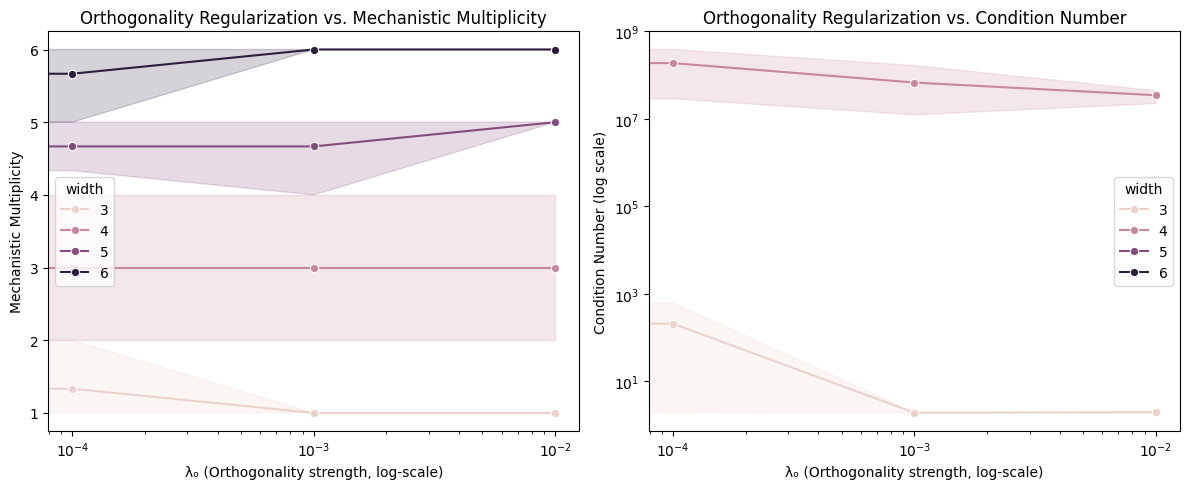

Correlation(log(cond), multiplicity) under orthogonalization: 0.874


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.lineplot(data=df_orth, x="lambda_orth", y="multiplicity", hue="width", marker="o")
plt.xscale("log")
plt.title("Orthogonality Regularization vs. Mechanistic Multiplicity")
plt.xlabel("λₒ (Orthogonality strength, log-scale)")
plt.ylabel("Mechanistic Multiplicity")

plt.subplot(1,2,2)
sns.lineplot(data=df_orth, x="lambda_orth", y="cond", hue="width", marker="o")
plt.xscale("log")
plt.yscale("log")
plt.title("Orthogonality Regularization vs. Condition Number")
plt.xlabel("λₒ (Orthogonality strength, log-scale)")
plt.ylabel("Condition Number (log scale)")

plt.tight_layout()
plt.show()

# replacing inf values in 'cond' with NaN for correlation calculation
df_corr = df_orth.replace([np.inf, -np.inf], np.nan).dropna(subset=['cond', 'multiplicity'])
corr_orth = np.corrcoef(np.log(df_corr["cond"]), df_corr["multiplicity"])[0,1]
print(f"Correlation(log(cond), multiplicity) under orthogonalization: {corr_orth:.3f}")

### Analysis of Trends and Ranges per Width

In [ ]:
print(' Multiplicity Trends')
for w in df_orth['width'].unique():
    df_w = df_orth[df_orth['width'] == w]
    multi_mean = df_w.groupby('lambda_orth')['multiplicity'].mean()
    multi_range = df_w.groupby('lambda_orth')['multiplicity'].apply(lambda x: f'{x.min()}-{x.max()}')
    print(f'\nWidth {w}:')
    print(f'  Multiplicity (mean across seeds, for each lambda_orth):\n{multi_mean}')
    print(f'  Multiplicity (range across seeds, for each lambda_orth):\n{multi_range}')

print('\nCondition Number (cond) Trends')
for w in df_orth['width'].unique():
    df_w = df_orth[df_orth['width'] == w].copy() # Using .copy() to avoid SettingWithCopyWarning
    # Have to replace inf with NaN for mean/range calculation, but remember the presence of inf
    df_w['cond_cleaned'] = df_w['cond'].replace([np.inf, -np.inf], np.nan)

    cond_mean = df_w.groupby('lambda_orth')['cond_cleaned'].mean()
    def cond_range_str(series):
        if np.isinf(series).any():
            return f'min:{series.min():.2f} to max:inf (some values are inf)'
        return f'min:{series.min():.2f} to max:{series.max():.2f}'

    cond_range = df_w.groupby('lambda_orth')['cond'].apply(cond_range_str)

    print(f'\nWidth {w}:')
    print(f'  Condition Number (mean across seeds, for each lambda_orth, excluding inf):\n{cond_mean}')
    print(f'  Condition Number (range across seeds, for each lambda_orth, including inf):\n{cond_range}')


 Multiplicity Trends

Width 3:
  Multiplicity (mean across seeds, for each lambda_orth):
lambda_orth
0.0000    1.000000
0.0001    1.333333
0.0010    1.000000
0.0100    1.000000
Name: multiplicity, dtype: float64
  Multiplicity (range across seeds, for each lambda_orth):
lambda_orth
0.0000    1-1
0.0001    1-2
0.0010    1-1
0.0100    1-1
Name: multiplicity, dtype: object

Width 4:
  Multiplicity (mean across seeds, for each lambda_orth):
lambda_orth
0.0000    3.0
0.0001    3.0
0.0010    3.0
0.0100    3.0
Name: multiplicity, dtype: float64
  Multiplicity (range across seeds, for each lambda_orth):
lambda_orth
0.0000    2-4
0.0001    2-4
0.0010    2-4
0.0100    2-4
Name: multiplicity, dtype: object

Width 5:
  Multiplicity (mean across seeds, for each lambda_orth):
lambda_orth
0.0000    4.666667
0.0001    4.666667
0.0010    4.666667
0.0100    5.000000
Name: multiplicity, dtype: float64
  Multiplicity (range across seeds, for each lambda_orth):
lambda_orth
0.0000    4-5
0.0001    4-5
0.001

In [ ]:
df_infinite_cond = df_orth[np.isinf(df_orth['cond']) & (df_orth['width'].isin([5, 6]))]
df_infinite_cond.head()

,width,seed,lambda_orth,eff_rank,cond,multiplicity
24,5,0,0.0000,2.977928,inf,5
25,5,0,0.0001,2.955488,inf,5
26,5,0,0.0010,2.984751,inf,5
27,5,0,0.0100,2.996084,inf,5
28,5,1,0.0000,2.872061,inf,4


In [ ]:
print(df_infinite_cond.to_string())

    width  seed  lambda_orth  eff_rank  cond  multiplicity
24      5     0       0.0000  2.977928   inf             5
25      5     0       0.0001  2.955488   inf             5
26      5     0       0.0010  2.984751   inf             5
27      5     0       0.0100  2.996084   inf             5
28      5     1       0.0000  2.872061   inf             4
29      5     1       0.0001  2.883584   inf             4
30      5     1       0.0010  2.987321   inf             5
31      5     1       0.0100  2.997435   inf             5
32      5     2       0.0000  2.970601   inf             5
33      5     2       0.0001  2.992687   inf             5
34      5     2       0.0010  2.870537   inf             4
35      5     2       0.0100  2.989831   inf             5
36      6     0       0.0000  2.948691   inf             6
37      6     0       0.0001  2.943395   inf             6
38      6     0       0.0010  2.960807   inf             6
39      6     0       0.0100  2.991516   inf            